### Wat wordt er voorspeld?
Het doel van deze regressieanalyse is om het totale aantal verhuurde fietsen per uur (`cnt`) te voorspellen. Hierbij worden verschillende factoren gebruikt zoals tijd (uur, maand, jaar), seizoenen en weersomstandigheden (temperatuur, luchtvochtigheid en windsnelheid).

### Waarom is deze dataset geschikt voor regressie?
Deze dataset is geschikt voor regressie omdat de doelvariabele `cnt` een continue numerieke waarde is die het aantal verhuurde fietsen per uur weergeeft. Daarnaast bevat de dataset meerdere onafhankelijke variabelen, zoals tijds-, kalender- en weersvariabelen, die mogelijk invloed hebben op het aantal fietsverhuringen.

### Data dictionary
- **instant** – Record index (numeriek)  
- **dteday** – Datum van de observatie (datum)  
- **season** – Seizoen (1 = lente, 2 = zomer, 3 = herfst, 4 = winter)  
- **yr** – Jaar (0 = 2011, 1 = 2012)  
- **mnth** – Maand (1–12)  
- **hr** – Uur van de dag (0–23)  
- **holiday** – Of de dag een feestdag is (0 = nee, 1 = ja)  
- **weekday** – Dag van de week (0–6)  
- **workingday** – Werkdag (0 = weekend/feestdag, 1 = werkdag)  
- **weathersit** – Weersituatie (1 = helder/bewolkt, 2 = mist/bewolkt, 3 = lichte regen/sneeuw, 4 = zware regen/sneeuw)  
- **temp** – Genormaliseerde temperatuur (numeriek)  
- **atemp** – Gevoelstemperatuur (genormaliseerd, numeriek)  
- **hum** – Genormaliseerde luchtvochtigheid (numeriek)  
- **windspeed** – Genormaliseerde windsnelheid (numeriek)  
- **casual** – Aantal casual gebruikers (numeriek)  
- **registered** – Aantal geregistreerde gebruikers (numeriek)  
- **cnt** – Totaal aantal verhuurde fietsen per uur (numeriek, target)

### Bron
Bike Sharing Dataset – UCI Machine Learning Repository  
https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset

### Data importeren en verkennen

In [7]:
import sklearn

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv("hour.csv")

df.info

<bound method DataFrame.info of        instant      dteday  season  yr  mnth  hr  holiday  weekday  \
0            1  2011-01-01       1   0     1   0        0        6   
1            2  2011-01-01       1   0     1   1        0        6   
2            3  2011-01-01       1   0     1   2        0        6   
3            4  2011-01-01       1   0     1   3        0        6   
4            5  2011-01-01       1   0     1   4        0        6   
...        ...         ...     ...  ..   ...  ..      ...      ...   
17374    17375  2012-12-31       1   1    12  19        0        1   
17375    17376  2012-12-31       1   1    12  20        0        1   
17376    17377  2012-12-31       1   1    12  21        0        1   
17377    17378  2012-12-31       1   1    12  22        0        1   
17378    17379  2012-12-31       1   1    12  23        0        1   

       workingday  weathersit  temp   atemp   hum  windspeed  casual  \
0               0           1  0.24  0.2879  0.81     0

In [9]:
df.head(5)

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [10]:
df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [11]:
df.dtypes

instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object

In [12]:
df['dteday'] = pd.to_datetime(df['dteday'])

# markeren dat de volgende kolommen categorisch zijn
cat_cols = ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit']
df[cat_cols] = df[cat_cols].astype('category')

df.dtypes  #dubbel checken

instant                int64
dteday        datetime64[ns]
season              category
yr                  category
mnth                category
hr                  category
holiday             category
weekday             category
workingday          category
weathersit          category
temp                 float64
atemp                float64
hum                  float64
windspeed            float64
casual                 int64
registered             int64
cnt                    int64
dtype: object

In [13]:
df.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

### target visualiseren en skewness controleren

C:\Users\Ian\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


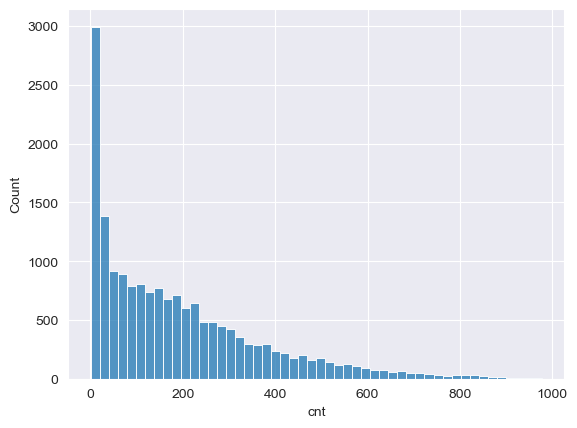

1.2774116037490577

In [14]:
sns.histplot(df['cnt'], bins=50)
plt.show()
df["cnt"].skew()

C:\Users\Ian\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='cnt', ylabel='Count'>

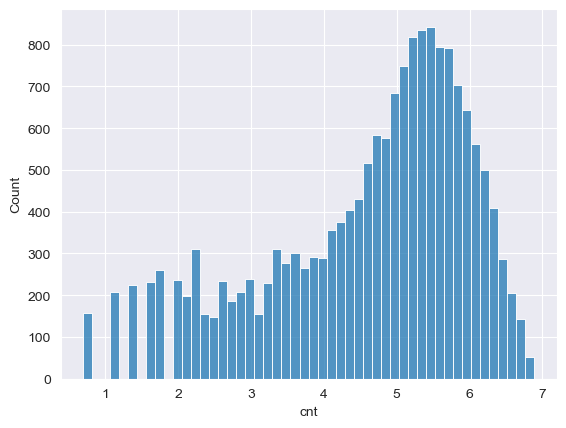

In [15]:
sns.histplot(np.log1p(df['cnt']), bins=50)

cnt is best wel skewed naar links, maar niet extreem. ik kies ervoor om de log-transformatie toe te passen. Dat zorgt later voor betere prestaties van het model

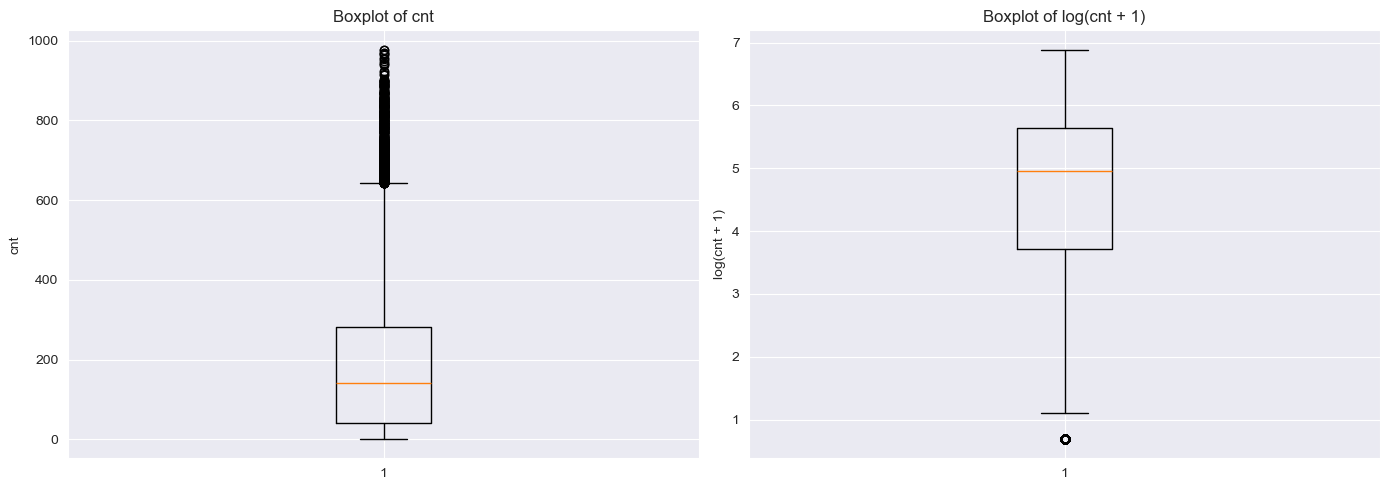

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(df['cnt'], vert=True)
axes[0].set_title('Boxplot of cnt')
axes[0].set_ylabel('cnt')

axes[1].boxplot(np.log1p(df['cnt']), vert=True)
axes[1].set_title('Boxplot of log(cnt + 1)')
axes[1].set_ylabel('log(cnt + 1)')

plt.tight_layout()
plt.show()

Er zijn enkele outliers in de `cnt`-variabele, maar na de log-transformatie zijn deze minder extreem. De log-transformatie helpt om de verdeling van de target variabele te normaliseren en kan de prestaties van het regressiemodel verbeteren.

### temporale trends visualiseren

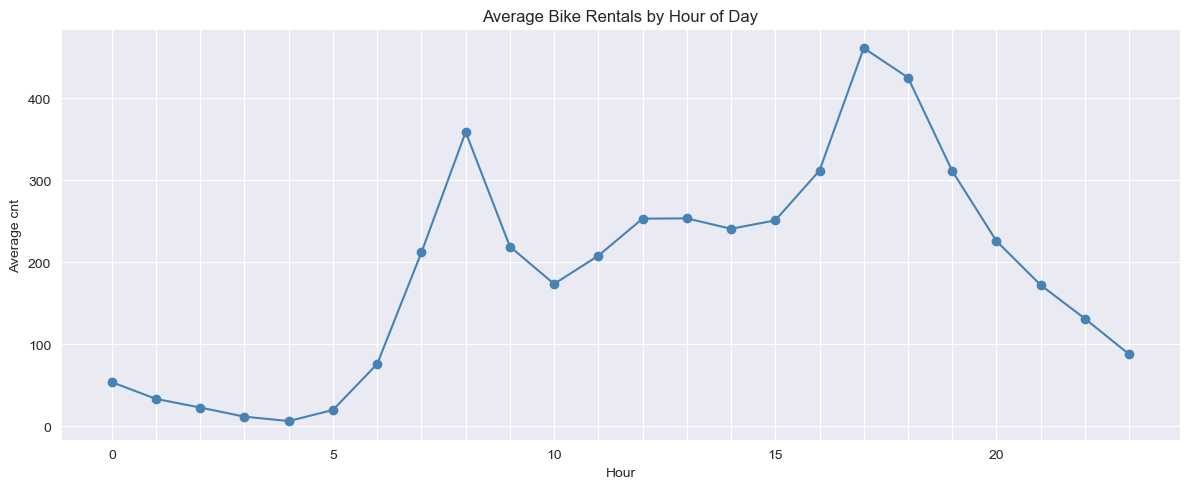

In [17]:
fig, ax = plt.subplots(figsize=(12, 5))

df.groupby('hr', observed=True)['cnt'].mean().plot(kind='line', marker='o', ax=ax, color='steelblue')
ax.set_title('Average Bike Rentals by Hour of Day')
ax.set_xlabel('Hour')
ax.set_ylabel('Average cnt')
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.show()

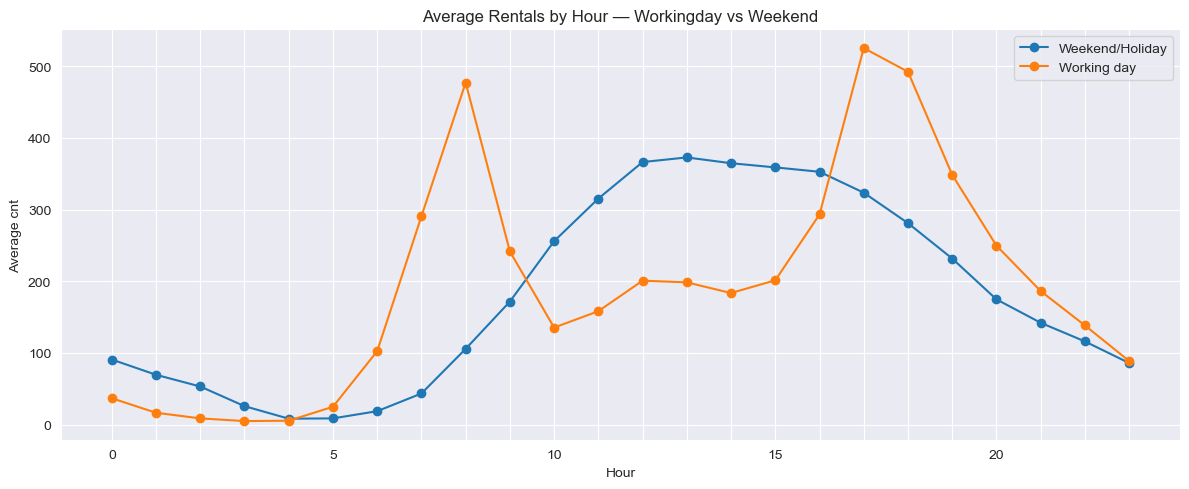

In [18]:
fig, ax = plt.subplots(figsize=(12, 5))

for label, group in df.groupby('workingday', observed=True):
    group.groupby('hr', observed=True)['cnt'].mean().plot(
        kind='line', marker='o', ax=ax,
        label='Working day' if str(label) == '1' else 'Weekend/Holiday'
    )

ax.set_title('Average Rentals by Hour — Workingday vs Weekend')
ax.set_xlabel('Hour')
ax.set_ylabel('Average cnt')
ax.set_xticks(range(0, 24))
ax.legend()
plt.tight_layout()
plt.show()

### weer & feature correlatie visualiseren 

In [19]:
weather_cols = ['temp', 'atemp', 'hum', 'windspeed']
df[weather_cols].describe()

,temp,atemp,hum,windspeed
count,17379.000000,17379.000000,17379.000000,17379.000000
mean,0.496987,0.475775,0.627229,0.190098
std,0.192556,0.171850,0.192930,0.122340
min,0.020000,0.000000,0.000000,0.000000
25%,0.340000,0.333300,0.480000,0.104500
50%,0.500000,0.484800,0.630000,0.194000
75%,0.660000,0.621200,0.780000,0.253700
max,1.000000,1.000000,1.000000,0.850700


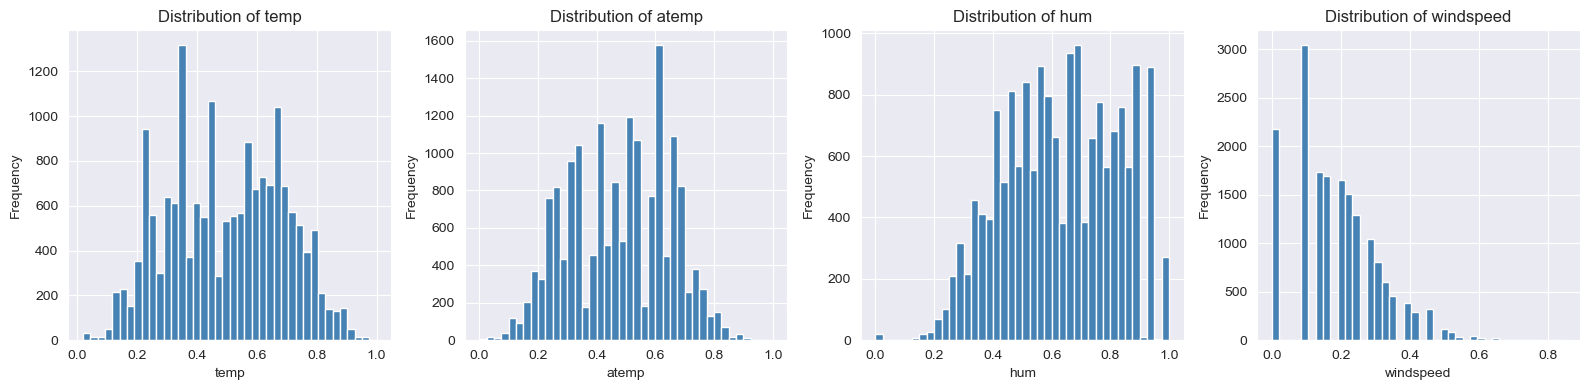

In [20]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, col in zip(axes, weather_cols):
    ax.hist(df[col], bins=40, color='steelblue', edgecolor='white')
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

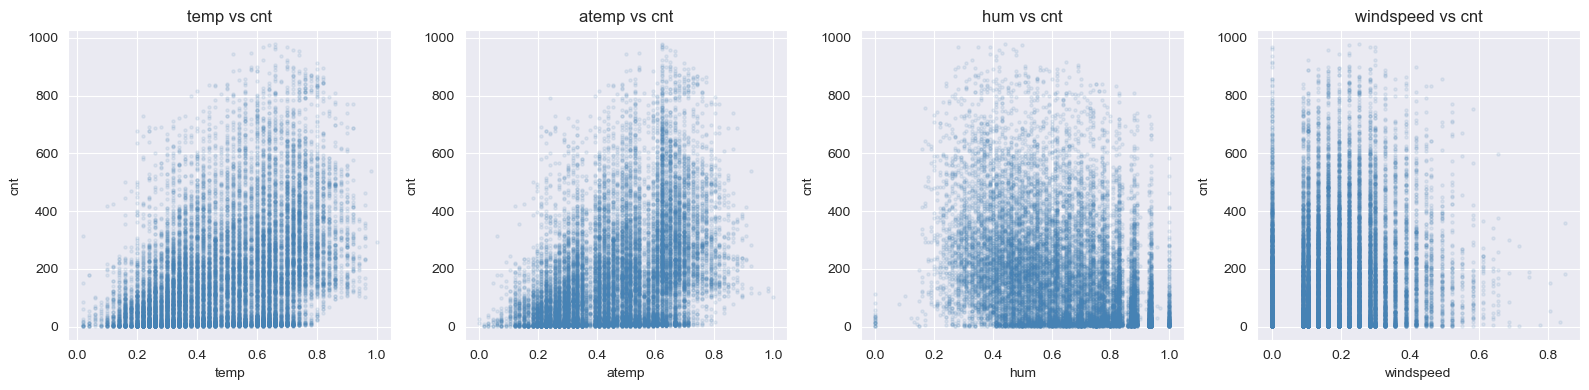

In [21]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, col in zip(axes, weather_cols):
    ax.scatter(df[col], df['cnt'], alpha=0.1, color='steelblue', s=5)
    ax.set_title(f'{col} vs cnt')
    ax.set_xlabel(col)
    ax.set_ylabel('cnt')

plt.tight_layout()
plt.show()

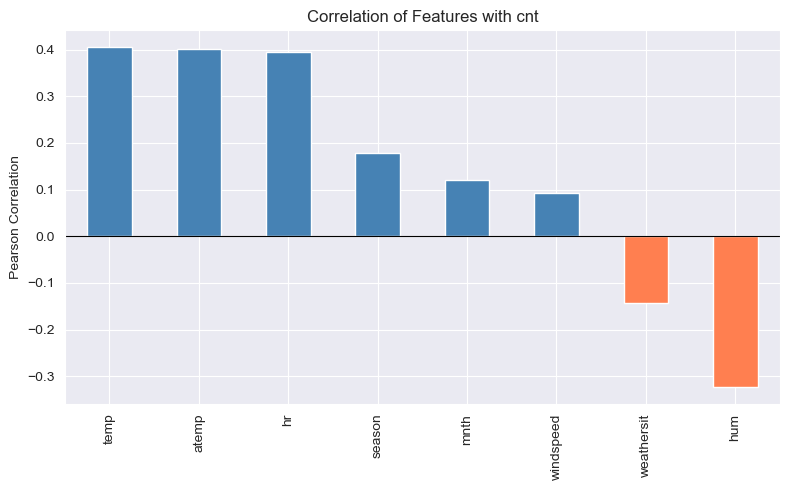

In [22]:
numeric_cols = ['temp', 'atemp', 'hum', 'windspeed', 'hr', 'mnth', 'season', 'weathersit', 'cnt']

corr_with_cnt = df[numeric_cols].apply(lambda x: x.astype(float)).corr()['cnt'].drop('cnt').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
corr_with_cnt.plot(kind='bar', ax=ax, color=['steelblue' if v > 0 else 'coral' for v in corr_with_cnt])
ax.set_title('Correlation of Features with cnt')
ax.set_ylabel('Pearson Correlation')
ax.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

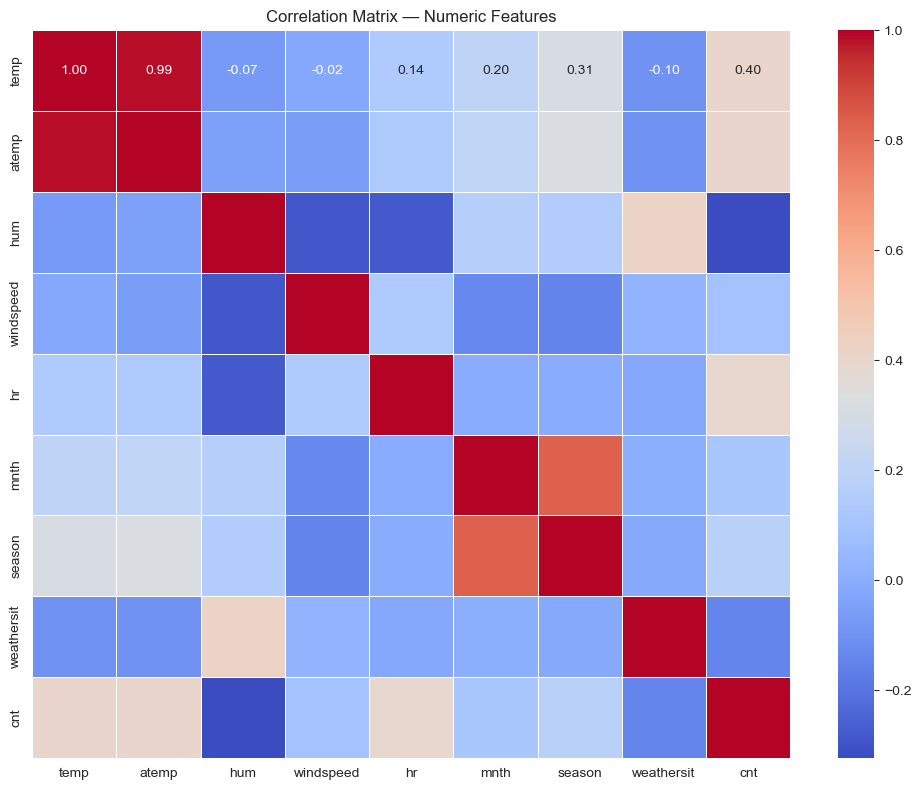

In [23]:
fig, ax = plt.subplots(figsize=(10, 8))

corr_matrix = df[numeric_cols].apply(lambda x: x.astype(float)).corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', ax=ax, linewidths=0.5)
ax.set_title('Correlation Matrix — Numeric Features')
plt.tight_layout()
plt.show()

**Bevindingen**

Uit de correlatieanalyse blijkt dat **temperatuur** (`temp`) de sterkste positieve correlatie 
heeft met het aantal fietsverhuren. Slechtere weersomstandigheden (`weathersit`) en hogere 
luchtvochtigheid (`hum`) hangen samen met minder verhuur. 

Opvallend is de zeer hoge correlatie tussen `temp` en `atemp` — deze twee variabelen meten 
nagenoeg hetzelfde. Om multicollineariteit te vermijden, zal `atemp` worden verwijderen uit het model misschien een handige stap zijn. daarom ga ik dit verder onderzoeken in de volgende stappen.

### multicollineariteit controleren

In [24]:
# casual and registered zorgen voor data leakage, atemp is bijna hetzelfde als temp, dus die ga ik ook verwijderen
drop_cols = ['casual', 'registered', 'atemp', 'dteday']
df_model = df.drop(columns=drop_cols)

print("Remaining columns:", df_model.columns.tolist())

Remaining columns: ['instant', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'hum', 'windspeed', 'cnt']


In [25]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# VIF needs float columns, no categoricals
vif_cols = ['temp', 'hum', 'windspeed', 'hr', 'mnth', 'season', 'weathersit', 'weekday', 'holiday', 'workingday', 'yr']

vif_data = df_model[vif_cols].apply(lambda x: x.astype(float))

vif_df = pd.DataFrame({
    'Feature': vif_cols,
    'VIF': [variance_inflation_factor(vif_data.values, i) for i in range(len(vif_cols))]
}).sort_values('VIF', ascending=False)

print(vif_df)

       Feature        VIF
5       season  21.058491
4         mnth  15.156499
1          hum  11.441489
0         temp   8.023689
6   weathersit   7.594574
3           hr   3.754495
9   workingday   3.227974
2    windspeed   3.213348
7      weekday   3.056419
10          yr   1.940106
8      holiday   1.095684


Waar ik naar zoek is een VIF-waarde boven de 5 of 10, wat kan duiden op problematische multicollineariteit. In dit geval hebben best wat features een VIF-waarde boven de 5, en sommige zelfs boven de 10, wat suggereert dat er multicollineariteit aanwezig is. De features `hr`, `mnth`, `season` en `weathersit` hebben de hoogste VIF-waarden, wat betekent dat ze sterk gecorreleerd zijn met andere features in het model. Om dit aan te pakken, zou ik kunnen overwegen om sommige van deze features te verwijderen.

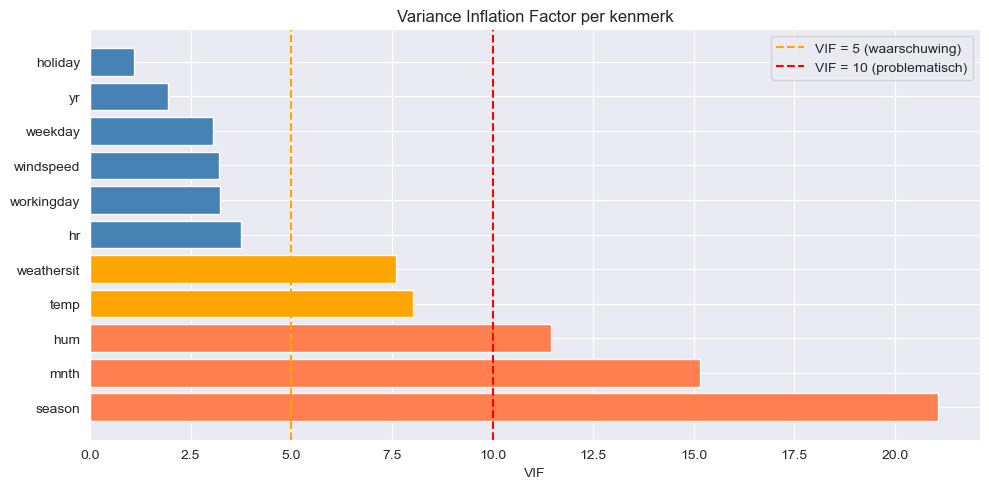

In [26]:
fig, ax = plt.subplots(figsize=(10, 5))

colors = ['coral' if v > 10 else 'orange' if v > 5 else 'steelblue' for v in vif_df['VIF']]
ax.barh(vif_df['Feature'], vif_df['VIF'], color=colors)
ax.axvline(x=5, color='orange', linestyle='--', label='VIF = 5 (waarschuwing)')
ax.axvline(x=10, color='red', linestyle='--', label='VIF = 10 (problematisch)')
ax.set_title('Variance Inflation Factor per kenmerk')
ax.set_xlabel('VIF')
ax.legend()
plt.tight_layout()
plt.show()

Ik heb er voor gekozen `mnth` te verwijderen omdat deze heel sterk correleert met `season`. Dit om multicollinearireit te verminderen 

In [27]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# VIF needs float columns, no categoricals
vif_cols = ['temp', 'hum', 'windspeed', 'hr', 'season', 'weathersit', 'weekday', 'holiday', 'workingday', 'yr']

vif_data = df_model[vif_cols].apply(lambda x: x.astype(float))

vif_df = pd.DataFrame({
    'Feature': vif_cols,
    'VIF': [variance_inflation_factor(vif_data.values, i) for i in range(len(vif_cols))]
}).sort_values('VIF', ascending=False)

print(vif_df)

      Feature        VIF
1         hum  11.385547
0        temp   7.925957
5  weathersit   7.594068
4      season   6.818913
3          hr   3.750525
8  workingday   3.227415
2   windspeed   3.213233
6     weekday   3.053826
9          yr   1.940025
7     holiday   1.093616


In [28]:
# dit is de uiteindelijke feauture set die ik ga gebruiken voor het model
feature_cols = ['temp', 'hum', 'windspeed', 'hr', 'season', 
                'weathersit', 'weekday', 'holiday', 'workingday', 'yr']

X = df_model[feature_cols].apply(lambda x: x.astype(float))
y = df_model['cnt'] 

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (17379, 10)
Target shape: (17379,)


zoals we zien verminderd dit de VIF-waarde van `season` 
wel zien we de VIF-waarde van `hum`, `temp` en `weathersit` nog steeds hoog is, maar ik ga er voor kiezen om deze te behouden omdat ze allemaal een sterke correlatie hebben met de target variabele en ik denk dat dit nogsteeds waardevolle infotrmatie toevoegt

**PS** ik heb toch gekozen voor de normale versie van `cnt` aangezien ik straks de RMSE scores wil vergelijken en de log-transformatie maakt de interpretatie van de RMSE minder intuïtief.

### train-test split en baseline models

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (13903, 10)
Test size: (3476, 10)


In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [31]:
#Linear regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print(f"Linear Regression — R²: {r2_lr:.4f} | RMSE: {rmse_lr:.2f}")

Linear Regression — R²: 0.3860 | RMSE: 139.44


In [32]:
#Random forest
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train) 
y_pred_rf = rf.predict(X_test)

r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print(f"Random Forest — R²: {r2_rf:.4f} | RMSE: {rmse_rf:.2f}")

Random Forest — R²: 0.9387 | RMSE: 44.04


In [33]:
#Gradient boosting
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

r2_gb = r2_score(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))

print(f"Gradient Boosting — R²: {r2_gb:.4f} | RMSE: {rmse_gb:.2f}")

Gradient Boosting — R²: 0.8549 | RMSE: 67.78


In [34]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Gradient Boosting'],
    'R²': [r2_lr, r2_rf, r2_gb],
    'RMSE': [rmse_lr, rmse_rf, rmse_gb]
})

results = results.sort_values('R²', ascending=False).reset_index(drop=True)
print(results)

               Model        R²        RMSE
0      Random Forest  0.938739   44.043688
1  Gradient Boosting  0.854925   67.777992
2  Linear Regression  0.386012  139.435235


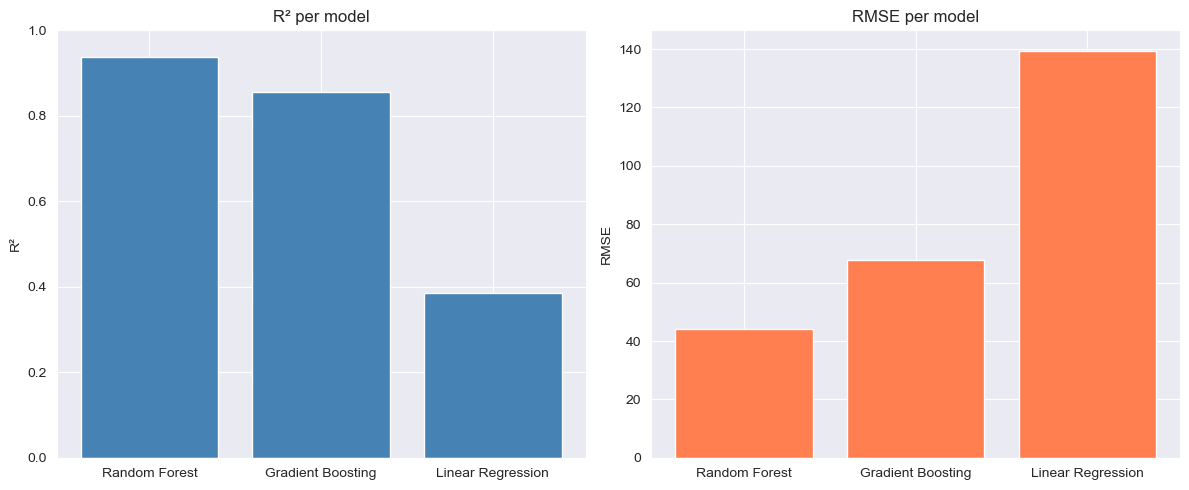

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(results['Model'], results['R²'], color='steelblue', edgecolor='white')
axes[0].set_title('R² per model')
axes[0].set_ylabel('R²')
axes[0].set_ylim(0, 1)

axes[1].bar(results['Model'], results['RMSE'], color='coral', edgecolor='white')
axes[1].set_title('RMSE per model')
axes[1].set_ylabel('RMSE')

plt.tight_layout()
plt.show()

### bevindingen model vergelijking
Zoals duidelijk te zien presteert het `Random Forest` model het beste met een **R²** van **0.94** en een **RMSE** van **44.04**. Dat betekent dat dit model 94% van de variatie in het aantal verhuurde fietsen kan verklaren, en de gemiddelde fout in de voorspellingen is ongeveer 44 fietsen per uur.

Het `Grandient boosting` model presteert niet slecht met een **R²** van **0.85**, maar de **RMSE** is aanzienlijk hoger dan die van het `Random Forest model`.

`Lineare regressie` presteert het slechtst met een **R²** van **0.39** en een **RMSE** van **139.44**, wat aangeeft dat dit model niet goed in staat is om de variatie in het aantal verhuurde fietsen te verklaren. 


In [36]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

pairwise_results = []

for col in feature_cols:
    X_single = X_train[[col]]
    X_single_test = X_test[[col]]
    
    model = LinearRegression()
    model.fit(X_single, y_train)
    y_pred = model.predict(X_single_test)
    
    r2 = r2_score(y_test, y_pred)
    pairwise_results.append({'Feature': col, 'R²': r2})

pairwise_df = pd.DataFrame(pairwise_results).sort_values('R²', ascending=False).reset_index(drop=True)
print(pairwise_df)

      Feature        R²
0        temp  0.167434
1          hr  0.161724
2         hum  0.099093
3          yr  0.050976
4      season  0.020946
5  weathersit  0.016672
6   windspeed  0.011007
7  workingday  0.000582
8     weekday -0.000724
9     holiday -0.000944


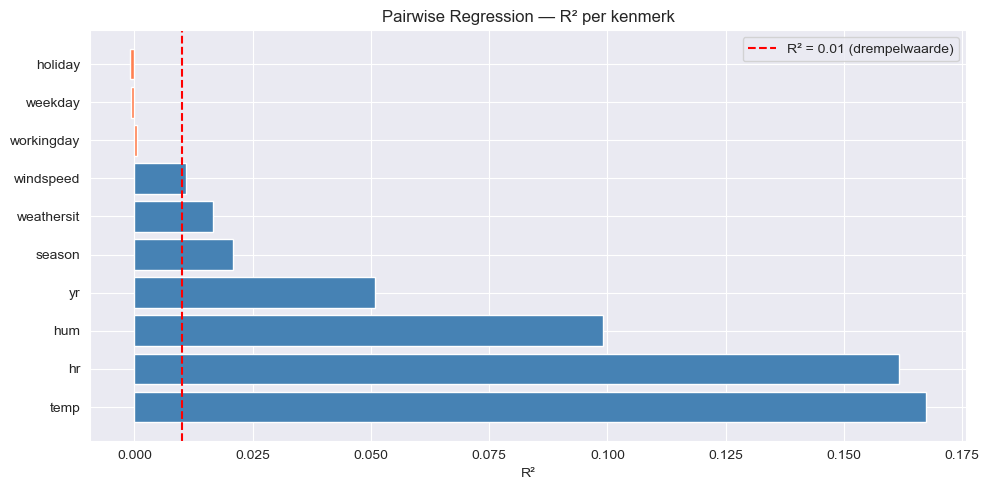

In [37]:
fig, ax = plt.subplots(figsize=(10, 5))

colors = ['steelblue' if r2 > 0.01 else 'coral' for r2 in pairwise_df['R²']]
ax.barh(pairwise_df['Feature'], pairwise_df['R²'], color=colors)
ax.axvline(x=0.01, color='red', linestyle='--', label='R² = 0.01 (drempelwaarde)')
ax.set_title('Pairwise Regression — R² per kenmerk')
ax.set_xlabel('R²')
ax.legend()
plt.tight_layout()
plt.show()

In [38]:
top_features = pairwise_df[pairwise_df['R²'] > 0.01]['Feature'].tolist()
print("Geselecteerde features:", top_features)

X_train_selected = X_train[top_features]
X_test_selected = X_test[top_features]

Geselecteerde features: ['temp', 'hr', 'hum', 'yr', 'season', 'weathersit', 'windspeed']


In [39]:
rf_selected = RandomForestRegressor(n_estimators=100, random_state=42)
rf_selected.fit(X_train_selected, y_train)
y_pred_rf_selected = rf_selected.predict(X_test_selected)

r2_selected = r2_score(y_test, y_pred_rf_selected)
rmse_selected = np.sqrt(mean_squared_error(y_test, y_pred_rf_selected))

print(f"Random Forest (geselecteerde features) — R²: {r2_selected:.4f} | RMSE: {rmse_selected:.2f}")
print(f"Random Forest (alle features)          — R²: {r2_rf:.4f} | RMSE: {rmse_rf:.2f}")

Random Forest (geselecteerde features) — R²: 0.7696 | RMSE: 85.41
Random Forest (alle features)          — R²: 0.9387 | RMSE: 44.04


### bevindingen feature selectie
Eerst keek ik alleen naar features met **R²** van 0.1. Dan zou ik alleen `temp` en `hr` over houden. Dus heb ik gekozen om de drempel te verlagen naar 0.01, wat resulteerde in het behouden van `temp`, `hr`, `hum`, `yr`, `season`, `weathersit`, `windspeed`. Toen ik deze subset van features gebruikte om een nieuw `Random Forest` model te trainen, zag ik dat de prestaties aanzienlijk afnemen zoals hierboven te zien. Dit suggereert dat hoewel sommige features weinig individuele voorspellende kracht hebben, ze in combinatie toch waardevolle informatie kunnen toevoegen aan het model. Daarom heb ik besloten om alle features te behouden voor het uiteindelijke model.

### trainen met volledige dataset

In [45]:
from sklearn.ensemble import RandomForestRegressor

rf_final = RandomForestRegressor(n_estimators=100, random_state=42)
rf_final.fit(X, y)  # volledige dataset, niet alleen X_train

print("Model getraind op volledige dataset")
print(f"Aantal observaties gebruikt: {X.shape[0]}")

Model getraind op volledige dataset
Aantal observaties gebruikt: 17379


In [49]:
import joblib

joblib.dump(rf_final, 'model.joblib' , compress=3)
print("Model opgeslagen als model.joblib ✓")

Model opgeslagen als model.joblib ✓


In [51]:
rf_loaded = joblib.load('model.joblib')
y_pred_check = rf_loaded.predict(X.head(5))

print("Model succesvol herladen ✓")
print("Testpredictie op 5 rijen:", y_pred_check)

Model succesvol herladen ✓
Testpredictie op 5 rijen: [21.72 33.23 24.37 11.93  1.91]
